# Figure 5 | LOI SHAP analysis

本 notebook 用当前 LOI 最终特征集和已调参的 ExtraTrees 重训模型生成 Figure 5 的 SHAP 图。所有版式参数集中在第 2 个代码单元，可单独调整。

**解释口径：**全数据重训模型的描述性 SHAP，不是 OOF-SHAP；其 nested-CV 性能从现有 `model_performance_summary.csv` 读取。

## 1. Imports and adjustable plotting parameters

所有以 `_IN` 结尾的参数单位为英寸。`axis_width_in` 与 `axis_height_in` 控制**图内坐标轴边框**的实际长度；外侧画布只为刻度和标签预留空间。

In [ ]:
from __future__ import annotations

import json
import re
from datetime import datetime, timezone
from pathlib import Path

import matplotlib
matplotlib.use('Agg')  # 在无图形界面的服务器中稳定导图
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
from rdkit import Chem, RDLogger
import shap
from sklearn.ensemble import ExtraTreesRegressor

# ===== 版式参数：可直接修改 =====
PLOT = {
    # 图内坐标轴边框的实际尺寸（x:y = 6.5:5.2）
    'axis_width_in': 6.5,
    'axis_height_in': 5.2,
    # 为加粗的标签/刻度预留的外侧边距
    'left_margin_in': 1.35,
    'bottom_margin_in': 1.05,
    'right_margin_in': 0.35,
    'top_margin_in': 0.25,
    # 字体、坐标轴和点的视觉样式
    'axis_label_size': 32,
    'tick_label_size': 28,
    'spine_width': 2.8,
    'tick_width': 1.8,
    'tick_length': 6,
    'dot_size': 36,
    'alpha': 1.0,
    # True 时导出的 SVG 使用透明画布和透明坐标轴底色。
    'transparent_background': True,
    # 输出：dependence 图只使用矢量格式
    'vector_formats': ('svg',),
    'raster_dpi': 600,
}

# ===== 字体设置：显式加载 Arial，避免 Matplotlib 回退为 DejaVu/Nimbus Sans =====
# 若在其他计算机运行，请把这两个路径改为该计算机的 Arial 字体文件路径。
FONT = {
    'family': 'Arial',
    'regular_path': Path('/mnt/c/Windows/Fonts/arial.ttf'),
    'bold_path': Path('/mnt/c/Windows/Fonts/arialbd.ttf'),
}
for font_path in (FONT['regular_path'], FONT['bold_path']):
    if not font_path.is_file():
        raise FileNotFoundError(f'Arial 字体文件不存在：{font_path}')
    font_manager.fontManager.addfont(str(font_path))
matplotlib.rcParams.update({
    'font.family': FONT['family'],
    'font.sans-serif': [FONT['family']],
    'pdf.fonttype': 42,       # 在 PDF 中嵌入 TrueType Arial
    'svg.fonttype': 'path',  # SVG 转为 Arial 字形路径，跨设备外观一致
})

TOP_GLOBAL_FEATURES = 20       # summary plot 显示的特征数
TOP_DEPENDENCE_FEATURES = 4    # 单独导出的 dependence 图数

# ===== SHAP summary 图专用参数：按需修改 =====
SUMMARY_PLOT = {
    # 内容：显示多少个最重要的 motif（与 TOP_GLOBAL_FEATURES 独立设置）
    'max_display': 20,
    # 画布尺寸：高度会随显示特征数量自动增长
    'width_in': 6.0,
    'base_height_in': 5.0,
    'height_per_feature_in': 0.35,
    # 图题和横轴标签：填 '' 可删除对应文字
    'title': '',
    'title_size': 20,
    'x_label': 'SHAP Value',
    'axis_label_size': 20,
    'tick_label_size': 20,
    # 右侧散点图与最长特征名右端之间的固定距离（单位：英寸）。
    'feature_to_plot_gap_in': 0.25,
    # 所有左侧特征名称共享同一中心点，因此名称居中且右端统一不压入散点区。
    'feature_label_alignment': 'center',
    # 加粗标题、轴标签与刻度文字；同时加粗刻度线。
    'font_weight': 'bold',
    'tick_width': 2.5,
    'tick_length': 6,
    # 横轴范围：None 代表使用自动范围；-10 保证左侧显示 -10 刻度
    'x_min': -10.0,
    'x_max': None,
    'extra_x_ticks': [-10.0],
    # 点：SHAP 原始默认点色为蓝-红；point_size 越大点越大
    'point_size': 36,
    'point_alpha': 1.0,
    'transparent_background': True,
    # 色条：False 删除右侧色条；可同时修改其标题
    'show_colorbar': True,
    'colorbar_label': 'Feature Value',
    # 色条位置 [left, bottom, width, height]；数值相对整个画布（0–1）。
    'colorbar_position': [0.875, 0.1, 0.028, 0.87],
    # 三个文字的位置 [x, y] 也相对整个画布；可单独移动。
    'feature_value_position': [0.955, 0.50],
    'high_position': [0.9, 0.955],
    'low_position': [0.9, 0.11],
    'colorbar_label_size': 20,
    'high_low_size': 20,
    'feature_value_rotation': 90,
    # summary 只导出 SVG 矢量图。
    'vector_formats': ('svg',),
    # 坐标轴边框：可改为 0 隐藏，或提高线宽
    'spine_width': 1.2,
}
RANDOM_STATE = 48
N_JOBS = 4
# 精确 Tree SHAP 会在当前深 ExtraTrees 上占用过多内存；True 使用稳定的近似树路径 SHAP。
SHAP_APPROXIMATE = True

# 项目根目录自动识别：支持从 YYJ、motif 或 LCMWR/scripts 打开 notebook。
# 若 notebook 被复制到项目外，可在此直接指定：PROJECT_ROOT = Path('/absolute/path/to/YYJ')
PROJECT_ROOT = None
if PROJECT_ROOT is None:
    cwd = Path.cwd().resolve()
    PROJECT_ROOT = next((candidate for candidate in (cwd, *cwd.parents)
                         if (candidate / 'LCMWR').is_dir()), None)
if PROJECT_ROOT is None:
    raise RuntimeError(f'无法从当前工作目录定位 YYJ 根目录：{Path.cwd()}。请在参数单元手动填写 PROJECT_ROOT。')
PROJECT_ROOT = Path(PROJECT_ROOT).resolve()
TASK = 'LOI'
MODEL_DIR = PROJECT_ROOT / 'LCMWR' / 'results' / 'model_compare' / TASK
OUTPUT_DIR = PROJECT_ROOT / 'LCMWR' / 'results' / 'interpretability' / TASK
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'Output directory: {OUTPUT_DIR}')

## 2. Load current final features and tuned ExtraTrees parameters

In [2]:
with (MODEL_DIR / 'run_config.json').open(encoding='utf-8') as handle:
    run_config = json.load(handle)
with (MODEL_DIR / 'best_params.json').open(encoding='utf-8') as handle:
    all_best_params = json.load(handle)
performance = pd.read_csv(MODEL_DIR / 'model_performance_summary.csv', encoding='utf-8-sig')

extra_record = all_best_params['ExtraTrees']
assert extra_record['status'] == 'success', 'ExtraTrees 参数文件没有成功记录。'
extra_params = {key.removeprefix('model__'): value for key, value in extra_record['best_params'].items()}
extra_cv_metrics = performance.loc[performance['model'].eq('ExtraTrees')].iloc[0].to_dict()

feature_path = Path(run_config['input_signature']['feature_matrix_path']['path'])
target_path = Path(run_config['resolved_input'])
target_column = run_config['target_column']
X = pd.read_csv(feature_path).astype(np.float32)
y = pd.read_csv(target_path, usecols=[target_column])[target_column].astype(np.float32)

assert X.columns.tolist() == run_config['feature_columns'], '特征顺序与模型比较记录不一致。'
assert len(X) == len(y) and not X.isna().any().any() and not y.isna().any(), '输入存在长度不一致或缺失值。'
print(f'Loaded {X.shape[0]} samples × {X.shape[1]} features')
print(f"Nested-CV ExtraTrees R²: {extra_cv_metrics['R2_mean']:.4f} ± {extra_cv_metrics['R2_std']:.4f}")

Loaded 948 samples × 149 features
Nested-CV ExtraTrees R²: 0.7866 ± 0.0385


## 3. Fit the explanatory ExtraTrees model and calculate SHAP values

ExtraTrees 在当前最终特征矩阵上重训；作图仍使用带原始 SMILES 标签的 `X`。

In [3]:
X_model = X.to_numpy(dtype=np.float32, copy=False)
model = ExtraTreesRegressor(
    random_state=RANDOM_STATE, n_jobs=N_JOBS, **extra_params,
)
model.fit(X_model, y.to_numpy(dtype=np.float32, copy=False))
shap_values = np.asarray(
    shap.TreeExplainer(model).shap_values(X_model, approximate=SHAP_APPROXIMATE)
)
assert shap_values.shape == X.shape, f'Unexpected SHAP shape: {shap_values.shape}'

# 仅用于图和表的显示名称：把可解析的 SMILES 规范为芳香简写，
# 例如 C1=CC=CC=C1 -> c1ccccc1；模型输入 X 的原始列名不变。
RDLogger.DisableLog('rdApp.error')
def short_smiles_label(feature_name):
    molecule = Chem.MolFromSmiles(feature_name)
    return Chem.MolToSmiles(molecule) if molecule is not None else feature_name

display_feature_names = [short_smiles_label(feature) for feature in X.columns]
feature_display_map = dict(zip(X.columns, display_feature_names))

ranking = pd.DataFrame({
    'feature': X.columns,
    'display_feature': display_feature_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
    'mean_shap': shap_values.mean(axis=0),
    'feature_mean': X.mean(axis=0).to_numpy(),
    'feature_std': X.std(axis=0).to_numpy(),
}).sort_values('mean_abs_shap', ascending=False, kind='stable').reset_index(drop=True)
ranking.insert(0, 'shap_rank', np.arange(1, len(ranking) + 1))
ranking['mean_abs_shap_percent'] = ranking['mean_abs_shap'] / ranking['mean_abs_shap'].sum() * 100
display(ranking.head(TOP_DEPENDENCE_FEATURES))

,shap_rank,feature,display_feature,mean_abs_shap,mean_shap,feature_mean,feature_std,mean_abs_shap_percent
0,1,C1=CC=CC=C1,c1ccccc1,1.797572,6.982225e-16,1.808087,2.120519,13.297966
1,2,C,C,1.088403,-3.091760e-17,16.789869,13.548911,8.051721
2,3,Br,Br,1.025735,5.271217e-16,0.124071,0.770784,7.588117
3,4,P,P,0.545814,6.581702e-17,0.293693,0.510140,4.037787


## 4. Export global SHAP summary plot

保留 PNG（便于快速查看）和 PDF（用于排版）；横轴会显式增加 `-10` 刻度。

In [4]:
# ===== SHAP summary 图：上述 SUMMARY_PLOT 参数均在这里生效 =====
n_global = min(SUMMARY_PLOT['max_display'], X.shape[1])
figure_height = max(
    SUMMARY_PLOT['base_height_in'],
    SUMMARY_PLOT['height_per_feature_in'] * n_global + 1.8,
)
plt.figure(figsize=(SUMMARY_PLOT['width_in'], figure_height))
shap.summary_plot(
    shap_values, X, feature_names=display_feature_names, max_display=n_global, plot_size=None, show=False,
    alpha=SUMMARY_PLOT['point_alpha'],
    color_bar=SUMMARY_PLOT['show_colorbar'],
    color_bar_label=SUMMARY_PLOT['colorbar_label'],
)
ax = plt.gca()
fig = plt.gcf()
if SUMMARY_PLOT['transparent_background']:
    fig.patch.set_alpha(0)
    ax.set_facecolor('none')
# 点大小：SHAP 画出的每一个散点集合统一使用此大小。
for collection in ax.collections:
    collection.set_sizes([SUMMARY_PLOT['point_size']])
# 标题和横轴标签。
ax.set_title(SUMMARY_PLOT['title'], fontsize=SUMMARY_PLOT['title_size'],
             fontweight=SUMMARY_PLOT['font_weight'])
ax.set_xlabel(SUMMARY_PLOT['x_label'], fontsize=SUMMARY_PLOT['axis_label_size'],
              fontweight=SUMMARY_PLOT['font_weight'])
# 横轴范围和额外刻度。
x_left, x_right = ax.get_xlim()
new_left = x_left if SUMMARY_PLOT['x_min'] is None else min(SUMMARY_PLOT['x_min'], x_left)
new_right = x_right if SUMMARY_PLOT['x_max'] is None else SUMMARY_PLOT['x_max']
ax.set_xlim(new_left, new_right)
x_ticks = np.unique(np.append(ax.get_xticks(), SUMMARY_PLOT['extra_x_ticks']))
ax.set_xticks(np.sort(x_ticks))
# 刻度文字和四条边框。
ax.tick_params(axis='both', labelsize=SUMMARY_PLOT['tick_label_size'],
               width=SUMMARY_PLOT['tick_width'], length=SUMMARY_PLOT['tick_length'])
ax.tick_params(axis='y', pad=0)
for label in [*ax.get_xticklabels(), *ax.get_yticklabels()]:
    label.set_fontweight(SUMMARY_PLOT['font_weight'])
for label in ax.get_yticklabels():
    label.set_horizontalalignment(SUMMARY_PLOT['feature_label_alignment'])
for spine in ax.spines.values():
    spine.set_linewidth(SUMMARY_PLOT['spine_width'])
# 下边框与横轴刻度线保持相同宽度。
ax.spines['bottom'].set_linewidth(SUMMARY_PLOT['tick_width'])
# 先完成基础布局，再按最长特征名的右端计算标签列位置。
plt.tight_layout()
fig = plt.gcf()
fig.canvas.draw()
renderer = fig.canvas.get_renderer()
feature_labels = ax.get_yticklabels()
max_label_width_px = max(label.get_window_extent(renderer).width for label in feature_labels)
axis_width_px = ax.get_window_extent(renderer).width
gap_px = SUMMARY_PLOT['feature_to_plot_gap_in'] * fig.dpi
label_center_x = -(gap_px + max_label_width_px / 2) / axis_width_px
for label in feature_labels:
    label.set_x(label_center_x)
    label.set_horizontalalignment(SUMMARY_PLOT['feature_label_alignment'])
# 色条和文字位置：主图位置已固定后，再按参数放置。
colorbar_axes = [other_ax for other_ax in fig.axes if other_ax is not ax]
if SUMMARY_PLOT['show_colorbar'] and colorbar_axes:
    colorbar_ax = colorbar_axes[0]
    colorbar_ax.set_position(SUMMARY_PLOT['colorbar_position'])
    colorbar_ax.set_ylabel('')
    colorbar_ax.set_yticks([])
    # Feature Value / High / Low 采用 fig.text，因此可完全独立调节位置和大小。
    fig.text(*SUMMARY_PLOT['feature_value_position'], SUMMARY_PLOT['colorbar_label'],
             rotation=SUMMARY_PLOT['feature_value_rotation'], va='center', ha='center',
             fontsize=SUMMARY_PLOT['colorbar_label_size'], fontweight=SUMMARY_PLOT['font_weight'])
    fig.text(*SUMMARY_PLOT['high_position'], 'High', va='center', ha='left',
             fontsize=SUMMARY_PLOT['high_low_size'], fontweight=SUMMARY_PLOT['font_weight'])
    fig.text(*SUMMARY_PLOT['low_position'], 'Low', va='center', ha='left',
             fontsize=SUMMARY_PLOT['high_low_size'], fontweight=SUMMARY_PLOT['font_weight'])
for suffix in SUMMARY_PLOT['vector_formats']:
    plt.savefig(OUTPUT_DIR / f'shap_summary_plot_LOI.{suffix}', bbox_inches='tight',
                transparent=SUMMARY_PLOT['transparent_background'])
plt.close()
ranking.head(n_global).to_csv(OUTPUT_DIR / 'shap_importance_top_features_LOI.csv', index=False)

## 5. Export four independent vector dependence plots

每张图：无上标题、左侧仅 `SHAP Value`、无右侧色条、四条边框均显示且加粗。修改第 1 节 `PLOT` 后，重新运行此单元即可。

In [5]:
def style_dependence_axis(ax):
    """统一依赖图的边框和文字；可在此微调样式。"""
    ax.set_title('')                         # 删除上标题
    ax.set_ylabel('SHAP Value', fontsize=PLOT['axis_label_size'], fontweight='bold')
    ax.xaxis.label.set_fontsize(PLOT['axis_label_size'])
    ax.xaxis.label.set_fontweight('bold')
    for spine in ax.spines.values():
        spine.set_visible(True)             # 显示上、右边框
        spine.set_linewidth(PLOT['spine_width'])
    ax.tick_params(axis='both', which='major', width=PLOT['tick_width'],
                   length=PLOT['tick_length'], labelsize=PLOT['tick_label_size'])
    for label in [*ax.get_xticklabels(), *ax.get_yticklabels()]:
        label.set_fontweight('bold')

def safe_file_stem(rank, feature):
    safe_feature = re.sub(r'[^A-Za-z0-9]+', '_', feature).strip('_')
    return f'shap_dependence_{rank:02d}_{safe_feature}_LOI'

figure_width = PLOT['left_margin_in'] + PLOT['axis_width_in'] + PLOT['right_margin_in']
figure_height = PLOT['bottom_margin_in'] + PLOT['axis_height_in'] + PLOT['top_margin_in']
axis_position = [
    PLOT['left_margin_in'] / figure_width,
    PLOT['bottom_margin_in'] / figure_height,
    PLOT['axis_width_in'] / figure_width,
    PLOT['axis_height_in'] / figure_height,
]

dependence_outputs = []
for rank, feature in enumerate(ranking.head(TOP_DEPENDENCE_FEATURES)['feature'], start=1):
    feature_index = X.columns.get_loc(feature)
    fig = plt.figure(figsize=(figure_width, figure_height))
    ax = fig.add_axes(axis_position)
    if PLOT['transparent_background']:
        fig.patch.set_alpha(0)
        ax.set_facecolor('none')
    shap.dependence_plot(
        feature_index, shap_values, X, feature_names=display_feature_names,
        interaction_index='auto', ax=ax, show=False,
        dot_size=PLOT['dot_size'], alpha=PLOT['alpha'],
    )
    # SHAP 自动创建的 interaction colour bar：按 Figure 5 要求删除。
    for extra_axis in list(fig.axes):
        if extra_axis is not ax:
            extra_axis.remove()
    ax.set_position(axis_position)  # 保证图内边框仍为 6.5 × 5.2 in
    style_dependence_axis(ax)
    stem = safe_file_stem(rank, feature)
    for suffix in PLOT['vector_formats']:
        fig.savefig(OUTPUT_DIR / f'{stem}.{suffix}', transparent=PLOT['transparent_background'])
    plt.close(fig)
    dependence_outputs.append({'rank': rank, 'feature': feature,
                               'display_feature': feature_display_map[feature],
                               'files': [f'{stem}.{suffix}' for suffix in PLOT['vector_formats']]})

# 输出格式可变：自动按 svg/pdf 等扩展名生成对应列。
dependence_file_rows = []
for item in dependence_outputs:
    row = {'rank': item['rank'], 'feature': item['feature'],
           'display_feature': item['display_feature']}
    row.update({Path(file_name).suffix.lstrip('.'): file_name for file_name in item['files']})
    dependence_file_rows.append(row)
dependence_file_table = pd.DataFrame(dependence_file_rows)
dependence_file_table.to_csv(OUTPUT_DIR / 'shap_dependence_plot_files_LOI.csv', index=False)
display(dependence_file_table)

,rank,feature,display_feature,svg
0,1,C1=CC=CC=C1,c1ccccc1,shap_dependence_01_C1_CC_CC_C1_LOI.svg
1,2,C,C,shap_dependence_02_C_LOI.svg
2,3,Br,Br,shap_dependence_03_Br_LOI.svg
3,4,P,P,shap_dependence_04_P_LOI.svg


## 6. Save reproducibility tables and metadata

In [ ]:
np.save(OUTPUT_DIR / 'shap_values_LOI.npy', shap_values)
pd.DataFrame(shap_values, columns=X.columns).to_csv(OUTPUT_DIR / 'shap_values_LOI.csv', index=False)
X.to_csv(OUTPUT_DIR / 'X_shap_LOI.csv', index=False)
y.to_frame(name=target_column).to_csv(OUTPUT_DIR / 'y_shap_LOI.csv', index=False)
pd.DataFrame({'LOI_predicted_full_refit': model.predict(X_model)}).to_csv(OUTPUT_DIR / 'y_pred_shap_LOI.csv', index=False)
ranking.to_csv(OUTPUT_DIR / 'shap_importance_ranking_LOI.csv', index=False)

metadata = {
    'created_at_utc': datetime.now(timezone.utc).isoformat(),
    'task': TASK, 'model': 'ExtraTreesRegressor', 'n_samples': int(X.shape[0]),
    'shap_algorithm': 'tree_path_approximate' if SHAP_APPROXIMATE else 'tree_path_exact',
    'n_features': int(X.shape[1]), 'plot_settings': PLOT,
    'tuned_model_parameters': extra_params,
    'nested_cv_performance_from_model_comparison': extra_cv_metrics,
    'explanation_scope': ('Full-data refit of ExtraTrees; descriptive SHAP, not OOF-SHAP. '
                              'Approximate tree-path SHAP is used to control memory.' if SHAP_APPROXIMATE else
                              'Full-data refit of ExtraTrees; descriptive SHAP, not OOF-SHAP.'),
    'top_dependence_plots': dependence_outputs,
}
(OUTPUT_DIR / 'run_metadata.json').write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding='utf-8')
print(f'Saved Figure 5 SHAP outputs to: {OUTPUT_DIR}')

## 7. Unified publication-style SVG override

使用与 T5、UL94 相同的 Figure 5 最终绘图逻辑覆盖同名 SVG；保留 LOI 的 `-10` 横轴刻度。

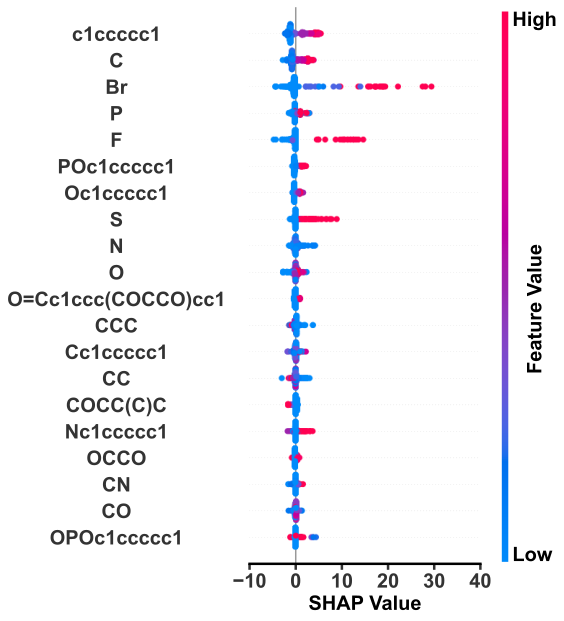

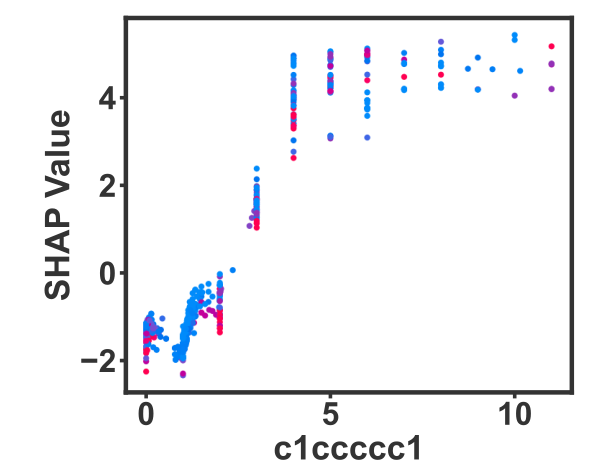

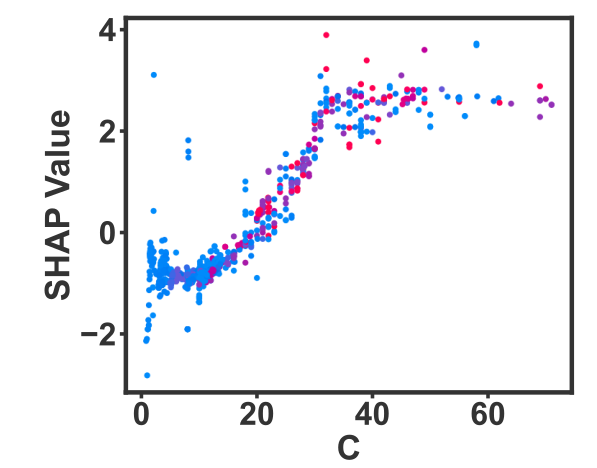

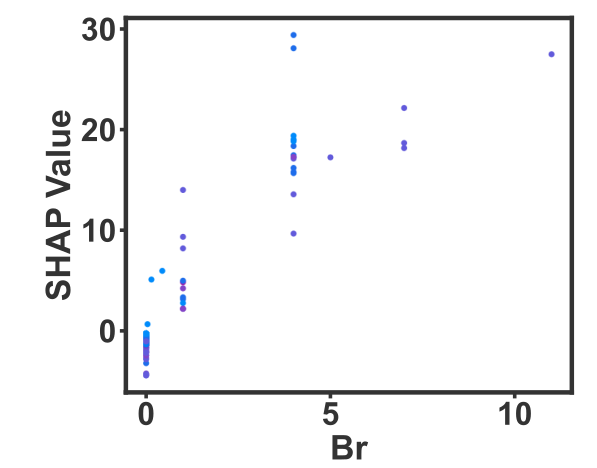

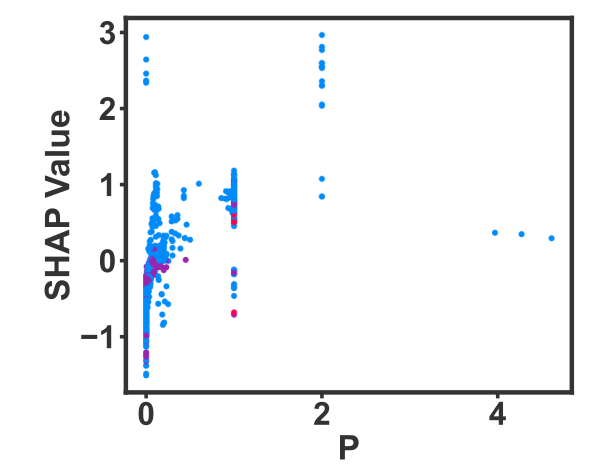

,rank,feature,display_feature,svg
0,1,C1=CC=CC=C1,c1ccccc1,shap_dependence_01_C1_CC_CC_C1_LOI.svg
1,2,C,C,shap_dependence_02_C_LOI.svg
2,3,Br,Br,shap_dependence_03_Br_LOI.svg
3,4,P,P,shap_dependence_04_P_LOI.svg


In [7]:
import sys
from IPython.display import SVG, display

SHAP_SCRIPT_DIR = PROJECT_ROOT / 'LCMWR' / 'scripts' / 'shap_analysis'
if str(SHAP_SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SHAP_SCRIPT_DIR))
from publication_shap_style import export_publication_shap_plots

# ===== Figure 5 样式参数：可直接修改 =====
PUBLICATION_PLOT = {
    'axis_width_in': 6.2, 'axis_height_in': 5.2,
    'left_margin_in': 1.75, 'bottom_margin_in': 1.05,
    'right_margin_in': 0.35, 'top_margin_in': 0.25,
    'axis_label_size': 34, 'y_axis_label_size': 34, 'tick_label_size': 32,
    'font_weight': 'bold', 'spine_width': 4.5, 'tick_width': 3.6, 'tick_length': 6,
    'dot_size': 36, 'alpha': 1.0, 'transparent_background': True,
}
PUBLICATION_SUMMARY = {
    'max_display': 20, 'width_in': 6.0, 'base_height_in': 5.0,
    'height_per_feature_in': 0.35, 'height_padding_in': 1.8,
    'axis_label_size': 20, 'tick_label_size': 20,
    'feature_to_plot_gap_in': 0.25, 'feature_label_alignment': 'center',
    'tick_width': 2.5, 'tick_length': 6, 'spine_width': 1.2,
    'point_size': 36, 'point_alpha': 1.0, 'show_colorbar': True,
    'colorbar_label': 'Feature Value',
    'colorbar_position': [0.875, 0.10, 0.028, 0.87],
    'feature_value_position': [0.955, 0.50],
    'high_position': [0.90, 0.955], 'low_position': [0.90, 0.11],
    'colorbar_label_size': 20, 'high_low_size': 20,
    'transparent_background': True,
}

summary_svg, publication_outputs = export_publication_shap_plots(
    task=TASK, output_dir=OUTPUT_DIR, features=X, shap_values=shap_values,
    ranking=ranking, display_names=display_feature_names, summary_x_label='SHAP Value',
    summary_tick_interval=None, summary_x_min=-10.0, summary_extra_x_ticks=(-10.0,),
    dependence_count=TOP_DEPENDENCE_FEATURES, plot=PUBLICATION_PLOT,
    summary=PUBLICATION_SUMMARY,
)
publication_outputs.to_csv(OUTPUT_DIR / 'shap_dependence_plot_files_LOI.csv', index=False)
display(SVG(filename=str(summary_svg)))
for svg_name in publication_outputs['svg']:
    display(SVG(filename=str(OUTPUT_DIR / svg_name)))
display(publication_outputs)
